# Notebook 01 — Préparation des Données

**Projet** : Prédiction du Churn Client  
**Dataset** : Telco Customer Churn (Kaggle)  
**Objectif** : Préparer le dataset pour qu'il soit utilisable par les modèles de Machine Learning.

Ce notebook couvre :
- a. Analyse de la qualité des données
- b. Analyse statistique descriptive
- c. Procédure de nettoyage

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Style global des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Chargement des données

In [2]:
df = pd.read_csv("../data/raw/telco_customer_churn.csv")

print("Taille du dataset :", df.shape)
print("Nombre de colonnes :", len(df.columns))

Taille du dataset : (7043, 21)
Nombre de colonnes : 21


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Analyse de la qualité des données

On vérifie que les données sont fiables avant de les utiliser.  
On cherche : les valeurs manquantes, les doublons et les types incorrects.

### 2.1 Types des colonnes

In [4]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [5]:
# TotalCharges devrait être un nombre, mais il est en string
# Cela vient de clients sans historique de facturation (valeur vide)
print("Type de TotalCharges :", df["TotalCharges"].dtype)

# On affiche les lignes problématiques
problemes = df[df["TotalCharges"].str.strip() == ""]
print("Nombre de lignes avec TotalCharges vide :", len(problemes))

Type de TotalCharges : str
Nombre de lignes avec TotalCharges vide : 11


### 2.2 Valeurs manquantes

In [6]:
# Nombre de valeurs manquantes par colonne
valeurs_manquantes = df.isnull().sum()
print("Colonnes avec valeurs manquantes :")
print(valeurs_manquantes[valeurs_manquantes > 0])

if valeurs_manquantes.sum() == 0:
    print("Aucune valeur manquante détectée (hors TotalCharges en string).")

Colonnes avec valeurs manquantes :
Series([], dtype: int64)
Aucune valeur manquante détectée (hors TotalCharges en string).


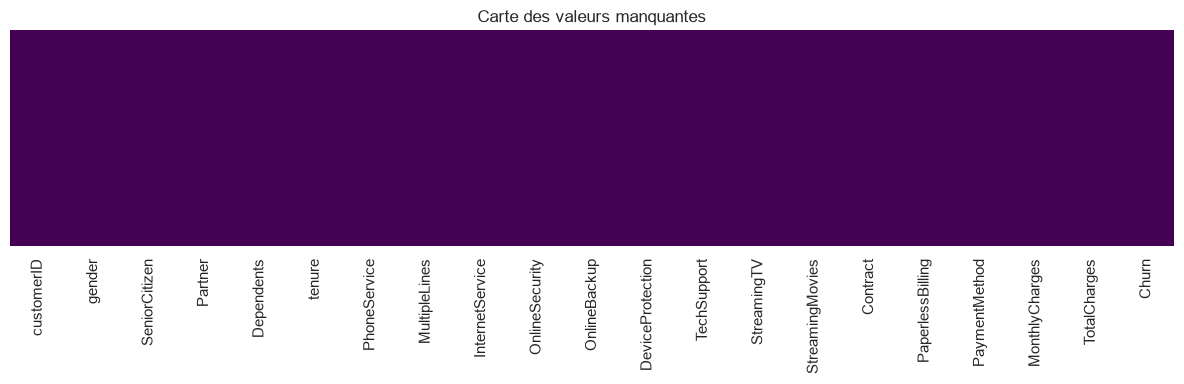

In [7]:
# Visualisation des valeurs manquantes
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Carte des valeurs manquantes")
plt.tight_layout()
plt.show()

### 2.3 Doublons

In [8]:
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons : {nb_doublons}")

Nombre de doublons : 0


### 2.4 Distribution de la cible (Churn)

In [9]:
# On vérifie si les classes sont équilibrées
print(df["Churn"].value_counts())
print()

taux_churn = df["Churn"].value_counts(normalize=True)["Yes"] * 100
print(f"Taux de churn : {taux_churn:.2f}%")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Taux de churn : 26.54%


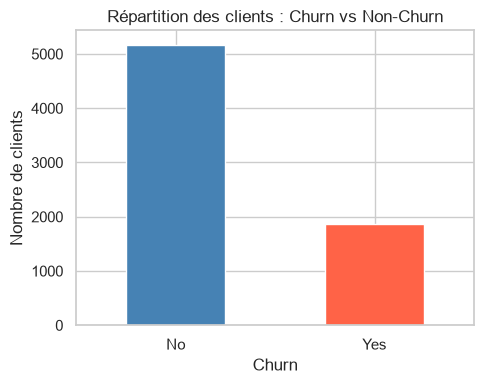

In [10]:
plt.figure(figsize=(5, 4))
df["Churn"].value_counts().plot(kind="bar", color=["steelblue", "tomato"], edgecolor="white")
plt.title("Répartition des clients : Churn vs Non-Churn")
plt.xlabel("Churn")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Analyse statistique descriptive

On explore les données pour comprendre la distribution des variables  
et repérer des patterns liés au churn.

### 3.1 Statistiques des variables numériques

In [11]:
df[["tenure", "MonthlyCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


### 3.2 Distribution des variables numériques

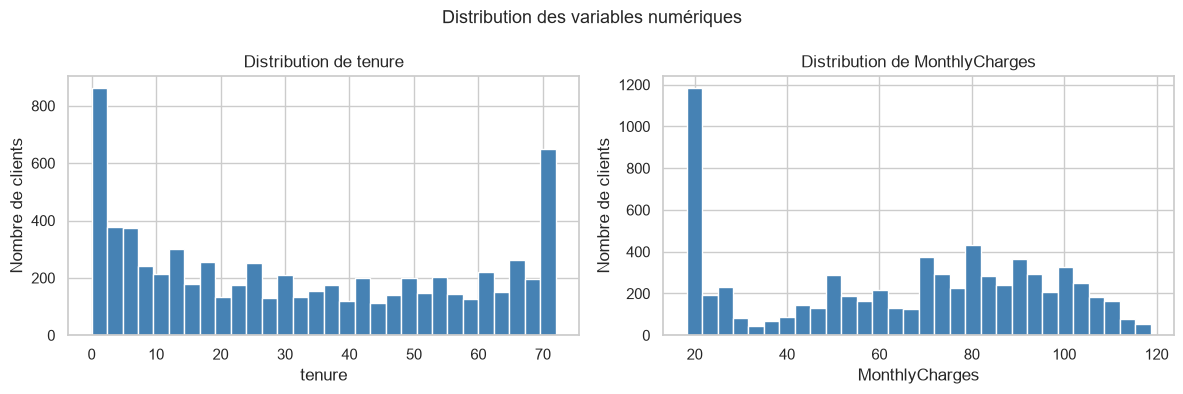

In [12]:
variables_numeriques = ["tenure", "MonthlyCharges"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(variables_numeriques):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre de clients")

plt.suptitle("Distribution des variables numériques", fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Variables numériques selon le churn

C:\Users\Adamo\AppData\Local\Temp\ipykernel_49664\2892610043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Adamo\AppData\Local\Temp\ipykernel_49664\2892610043.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


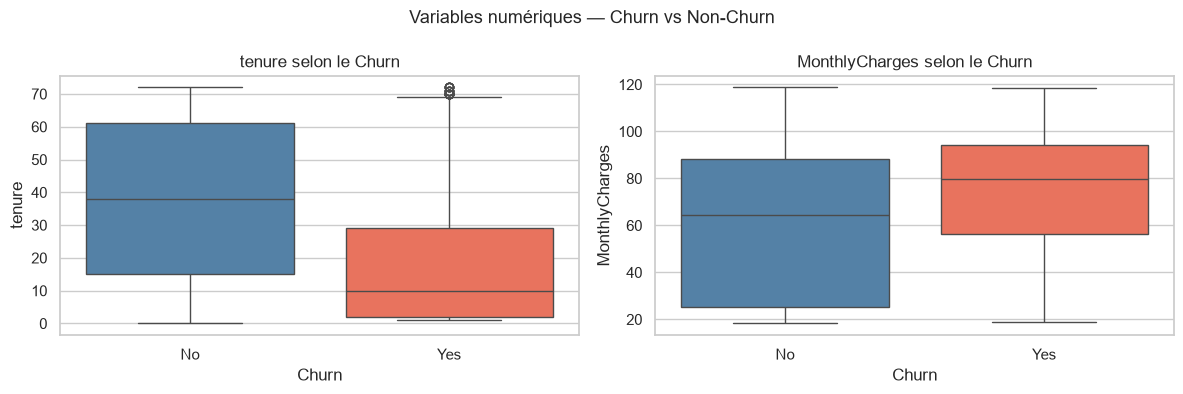

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(variables_numeriques):
    sns.boxplot(
        data=df,
        x="Churn",
        y=col,
        ax=axes[i],
        palette={"No": "steelblue", "Yes": "tomato"}
    )
    axes[i].set_title(f"{col} selon le Churn")

plt.suptitle("Variables numériques — Churn vs Non-Churn", fontsize=13)
plt.tight_layout()
plt.show()

### 3.4 Variables catégorielles selon le churn

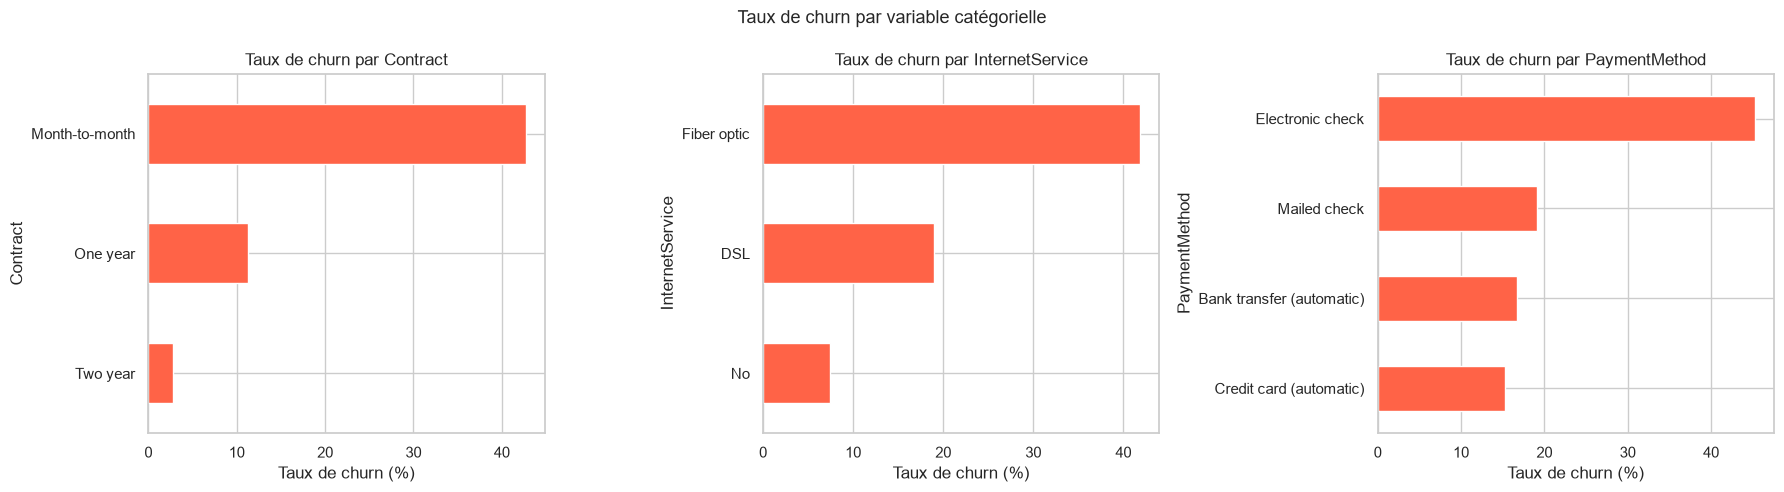

In [14]:
variables_cat = ["Contract", "InternetService", "PaymentMethod"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(variables_cat):
    # On calcule le taux de churn pour chaque catégorie
    taux = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
    taux.sort_values().plot(kind="barh", ax=axes[i], color="tomato", edgecolor="white")
    axes[i].set_title(f"Taux de churn par {col}")
    axes[i].set_xlabel("Taux de churn (%)")

plt.suptitle("Taux de churn par variable catégorielle", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Nettoyage des données

On applique les corrections identifiées dans l'analyse qualité.

In [15]:
# On travaille sur une copie pour ne pas modifier l'original
df_clean = df.copy()

### 4.1 Correction de TotalCharges

In [16]:
# Les clients avec tenure=0 ont une valeur vide dans TotalCharges
# On convertit en float et on remplace les vides par 0
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

print("Type après correction :", df_clean["TotalCharges"].dtype)
print("Valeurs manquantes restantes :", df_clean["TotalCharges"].isnull().sum())

Type après correction : float64
Valeurs manquantes restantes : 0


### 4.2 Suppression de customerID

In [17]:
# customerID est un identifiant unique — il n'apporte aucune information au modèle
df_clean = df_clean.drop(columns=["customerID"])

print("Colonnes restantes :", df_clean.shape[1])

Colonnes restantes : 20


### 4.3 Encodage de la cible (Churn)

In [18]:
# On convertit Yes/No en 1/0 pour que le modèle puisse le lire
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

print("Valeurs de Churn :", df_clean["Churn"].unique())

Valeurs de Churn : [0 1]


### 4.4 Encodage des variables binaires

In [19]:
# Toutes les colonnes Yes/No → 1/0
colonnes_binaires = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in colonnes_binaires:
    df_clean[col] = df_clean[col].map({"Yes": 1, "No": 0})

print("Encodage binaire terminé.")
df_clean[colonnes_binaires].head()

Encodage binaire terminé.


,Partner,Dependents,PhoneService,PaperlessBilling
0,1,0,0,1
1,0,0,1,0
2,0,0,1,1
3,0,0,0,0
4,0,0,1,1


### 4.5 Encodage des variables catégorielles (One-Hot Encoding)

In [20]:
# Les colonnes avec plusieurs catégories → on crée une colonne par catégorie
# drop_first=True évite la multicolinéarité
colonnes_avant = df_clean.shape[1]

df_clean = pd.get_dummies(df_clean, drop_first=True)

colonnes_apres = df_clean.shape[1]
print(f"Colonnes avant : {colonnes_avant}  →  Colonnes après : {colonnes_apres}")

Colonnes avant : 20  →  Colonnes après : 31


### 4.6 Normalisation des variables numériques

In [21]:
# On normalise les variables numériques
# Cela évite qu'une variable avec de grandes valeurs domine le modèle
variables_a_normaliser = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
df_clean[variables_a_normaliser] = scaler.fit_transform(df_clean[variables_a_normaliser])

print("Moyennes après normalisation (doivent être proches de 0) :")
print(df_clean[variables_a_normaliser].mean().round(4))

Moyennes après normalisation (doivent être proches de 0) :
tenure           -0.0
MonthlyCharges   -0.0
TotalCharges     -0.0
dtype: float64


## 5. Vérification finale

In [22]:
print("Taille du dataset nettoyé :", df_clean.shape)
print()
print("Types des colonnes :")
print(df_clean.dtypes.value_counts())
print()
print("Valeurs manquantes :", df_clean.isnull().sum().sum())

Taille du dataset nettoyé : (7043, 31)

Types des colonnes :
bool       22
int64       6
float64     3
Name: count, dtype: int64

Valeurs manquantes : 0


In [23]:
df_clean.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,-1.277445,0,1,-1.160323,-0.992611,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0.066327,1,0,-0.259629,-0.172165,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,-1.236724,1,1,-0.362660,-0.958066,1,True,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,0.514251,0,0,-0.746535,-0.193672,0,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,-1.236724,1,1,0.197365,-0.938874,1,False,...,False,False,False,False,False,False,False,False,True,False


## 6. Sauvegarde du dataset nettoyé

In [24]:
df_clean.to_csv("../data/processed/cleaned_telco.csv", index=False)

print("Dataset nettoyé sauvegardé dans data/processed/cleaned_telco.csv")

Dataset nettoyé sauvegardé dans data/processed/cleaned_telco.csv


## Conclusion

Le dataset est maintenant prêt pour la phase de modélisation :

- **Problèmes corrigés** : TotalCharges converti en float (11 valeurs vides → 0), customerID supprimé
- **Encodage** : variables binaires et catégorielles converties en nombres
- **Normalisation** : tenure, MonthlyCharges et TotalCharges standardisés (moyenne ≈ 0)
- **Déséquilibre de classes** : environ 26% de churners — à prendre en compte lors de la modélisation